# Intelligent Warehouse Robot Navigation
## D3: Implementation – Algorithms & Visualization

This notebook implements all search algorithms for the Warehouse Robot Navigation problem as defined in D1 and D2.

### Problem Summary
- Robot navigates an **N×N grid** from `(0,0)` → `(N-1, N-1)`
- Grid contains **static obstacles** and **k weighted items**
- Robot has a fixed **energy budget E₀** (each move costs 1 energy)
- **Objective**: Maximize total collected weight `W(π)` subject to `L(π) ≤ E₀`

### Algorithms Implemented
1. **BFS** – Breadth-First Search (uninformed)
2. **UCS** – Uniform Cost Search (uninformed)
3. **Greedy Best-First Search** (informed, uses h1 or h2)
4. **A\*** (informed, uses h1 or h2)
5. **Modified A\*** – Branch-and-Bound A* for maximum weight (optimal)

### Heuristics
- **h1**: Manhattan distance to nearest remaining item (or delivery)
- **h2**: h1 + MST over remaining items + distance from last item to delivery

## Importing all required libraries

In [9]:
!pip install numpy
!pip install matplotlib


In [17]:
from collections import deque
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import random

## Environment – Grid, State, and Problem Definition

We define the `WarehouseEnv` class which encapsulates:
- The N×N grid with obstacles
- Item positions and weights
- State representation: `(x, y, remaining_items_frozenset, energy)`
- Transition model T(s, a)
- Visualization

In [18]:
class WarehouseEnv:
    """
    State is represented by (x, y, remaining_items_frozenset, energy)
    where (x, y) is the current position of the robot, remaining_items_frozenset is a frozenset of indices of items not yet collected, and energy is the remaining energy of the robot.
    Grid convention: (0,0) = top-left, (N-1,N-1) = bottom-right.
    Directions: Up=(-1,0), Down=(+1,0), Left=(0,-1), Right=(0,+1)
    """
    DIRECTIONS = {
        'UP':    (-1,  0),
        'DOWN':  ( 1,  0),
        'LEFT':  ( 0, -1),
        'RIGHT': ( 0,  1),
    }

    def __init__(self, N: int, energy: int, obstacle_positions: list,
                 item_positions: list, item_weights: list, seed: int = 42):
        """
        Parameters
        ----------
        N                  : grid size (N x N)
        energy             : initial energy budget E0
        obstacle_positions : list of (row, col) tuples
        item_positions     : list of (row, col) tuples (one per item)
        item_weights       : list of int weights (one per item)
        seed               : random seed (for reproducibility)
        """
        assert N >= 2, "Grid must be at least 2x2"
        assert len(item_positions) == len(item_weights), "Mismatch: positions vs weights"

        self.N = N
        self.E0 = energy
        self.obstacles = set(map(tuple, obstacle_positions))  # fast lookup for blocked cells
        self.item_positions = [tuple(p) for p in item_positions]   # index -> (r,c)
        self.item_weights = list(item_weights)                   # index -> weight
        self.k = len(item_positions)                             # number of items
        self.start = (0, 0)
        self.goal = (N-1, N-1)

        # Build a position -> item_index lookup for quick checks during state transitions
        self.pos_to_item = {pos: idx for idx, pos in enumerate(self.item_positions)}

        # Validate: no obstacles or items on start/goal
        assert self.start not in self.obstacles, "Start cell is blocked!"
        assert self.goal not in self.obstacles, "Goal cell is blocked!"
        for pos in self.item_positions:
            assert pos not in self.obstacles, f"Item at {pos} overlaps obstacle!"

    def initial_state(self):
        """s0 = (0, 0, frozenset(all item indices), E0)"""
        return (0, 0, frozenset(range(self.k)), self.E0)

    def is_goal(self, state) -> bool:
        x, y, _, e = state
        return (x, y) == self.goal and e >= 0

    def collected_weight(self, state) -> int:
        """Weight of items collected so far (i.e. NOT in remaining set)."""
        _, _, remaining, _ = state
        return sum(self.item_weights[i] for i in range(self.k)
                   if i not in remaining)

    # Transition model T(s, a) -> s'
    def get_successors(self, state):
        """
        Returns list of (action_name, successor_state, step_cost).

        Actions:
        Move(dir)  - cost 1, valid if adjacent cell is in-grid and not obstacle,
                    and e > 0.
        Pickup(i)  - cost 0, valid if robot is on item i and i in remaining.
                    (Auto-applied after each move in most algorithms, but
                    modeled as explicit action here for completeness.)
        """
        x, y, remaining, e = state
        successors = []

        # Move actions
        if e > 0:
            for name, (dr, dc) in self.DIRECTIONS.items():
                nx, ny = x + dr, y + dc
                if 0 <= nx < self.N and 0 <= ny < self.N:
                    if (nx, ny) not in self.obstacles:
                        new_e = e - 1
                        new_rem = remaining
                        # Auto-pickup if the new cell has an item
                        if (nx, ny) in self.pos_to_item:
                            idx = self.pos_to_item[(nx, ny)]
                            if idx in remaining:
                                new_rem = remaining - {idx}
                        new_state = (nx, ny, new_rem, new_e)
                        successors.append((f'Move({name})', new_state, 1))

        return successors

    # Grid validation
    def is_reachable(self) -> bool:
        """BFS check: is goal reachable from start ignoring energy?"""
        visited = {self.start}
        queue = deque([self.start])
        while queue:
            x, y = queue.popleft()
            if (x, y) == self.goal:
                return True
            for dr, dc in self.DIRECTIONS.values():
                nx, ny = x + dr, y + dc
                if (0 <= nx < self.N and 0 <= ny < self.N
                        and (nx, ny) not in self.obstacles
                        and (nx, ny) not in visited):
                    visited.add((nx, ny))
                    queue.append((nx, ny))
        return False

    # Visualization
    def render(self, path=None, title='Warehouse Grid', ax=None,
               explored=None, figsize=(7, 7)):
        """
        Render the warehouse grid.

        Color coding:
          White     = free cell
          Black     = obstacle
          Green     = start (0,0)
          Red       = goal  (N-1,N-1)
          Yellow    = item
          Blue      = path (if provided)
          LightBlue = explored cells (if provided)
        """
        show = ax is None
        if show:
            fig, ax = plt.subplots(figsize=figsize)

        grid = np.zeros((self.N, self.N))  # 0 = free

        for (r, c) in self.obstacles:
            grid[r][c] = 1  # obstacle

        if explored:
            for (r, c) in explored:
                if grid[r][c] == 0:
                    grid[r][c] = 5  # explored

        if path:
            for (r, c) in path:
                if grid[r][c] == 0 or grid[r][c] == 5:
                    grid[r][c] = 3  # path

        for (r, c) in self.item_positions:
            if grid[r][c] == 0:
                grid[r][c] = 2  # item

        grid[self.start] = 6  # start
        grid[self.goal] = 4   # goal

        # Mark items on path (collected)
        if path:
            path_set = set(path)
            for (r, c) in self.item_positions:
                if (r, c) in path_set:
                    grid[r][c] = 7  # collected item on path

        cmap = ListedColormap([
            '#FFFFFF',  # 0 free
            '#2C2C2C',  # 1 obstacle
            '#FFD700',  # 2 item
            '#4A90D9',  # 3 path
            '#E74C3C',  # 4 goal
            '#D0EAF8',  # 5 explored
            '#2ECC71',  # 6 start
            '#F39C12',  # 7 collected item on path
        ])

        ax.imshow(grid, cmap=cmap, vmin=0, vmax=7, origin='upper')

        # Grid lines
        for i in range(self.N + 1):
            ax.axhline(i - 0.5, color='#CCCCCC', linewidth=0.5)
            ax.axvline(i - 0.5, color='#CCCCCC', linewidth=0.5)

        # Item weight labels
        for idx, (r, c) in enumerate(self.item_positions):
            ax.text(c, r, f'W{self.item_weights[idx]}',
                    ha='center', va='center', fontsize=7,
                    color='#333333', fontweight='bold')

        # Start / Goal labels
        ax.text(0, 0, 'S', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
        ax.text(self.N - 1, self.N - 1, 'G', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

        # Legend
        legend_elements = [
            mpatches.Patch(color='#2ECC71', label='Start'),
            mpatches.Patch(color='#E74C3C', label='Goal'),
            mpatches.Patch(color='#2C2C2C', label='Obstacle'),
            mpatches.Patch(color='#FFD700', label='Item (uncollected)'),
            mpatches.Patch(color='#F39C12', label='Item (collected)'),
            mpatches.Patch(color='#4A90D9', label='Path'),
            mpatches.Patch(color='#D0EAF8', label='Explored'),
        ]
        ax.legend(handles=legend_elements, loc='upper left',
                  bbox_to_anchor=(1.01, 1), fontsize=8)

        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xticks(range(self.N))
        ax.set_yticks(range(self.N))
        ax.tick_params(labelsize=7)

        if show:
            plt.tight_layout()
            plt.show()

print("WarehouseEnv defined.")

WarehouseEnv defined.


## Problem Factory – Easy / Medium / Hard Instances

We define three test instances that will be reused across all algorithms for comparison.

In [19]:
def make_problem(difficulty='easy', seed=42):
    """
    Returns a WarehouseEnv configured as easy / medium / hard.

    Easy  : 5x5,  E0=10,  5 items,  ~10% obstacles
    Medium: 8x8,  E0=20, 10 items,  ~15% obstacles
    Hard  : 10x10,  E0=30, 15 items,  ~20% obstacles
    """
    rng = random.Random(seed)  # keep this reproducible

    configs = {
        'easy':   dict(N=5, energy=10, n_items=5,  obstacle_frac=0.10),
        'medium': dict(N=8, energy=20, n_items=10, obstacle_frac=0.15),
        'hard':   dict(N=10, energy=30, n_items=15, obstacle_frac=0.20),
    }
    cfg = configs[difficulty]
    N, E0, n_items, obs_frac = (cfg['N'], cfg['energy'],
                                cfg['n_items'], cfg['obstacle_frac'])

    forbidden = {(0, 0), (N-1, N-1)}  # don't place stuff on start/goal
    all_cells = [(r, c) for r in range(N) for c in range(N)
                 if (r, c) not in forbidden]
    rng.shuffle(all_cells)

    n_obs  = int(N * N * obs_frac)
    obstacles = all_cells[:n_obs]
    remaining_cells = [c for c in all_cells[n_obs:]
                       if c not in set(obstacles)]
    rng.shuffle(remaining_cells)
    item_positions = remaining_cells[:n_items]
    item_weights   = [rng.randint(1, 20) for _ in range(n_items)]

    env = WarehouseEnv(
        N=N, energy=E0,
        obstacle_positions=obstacles,
        item_positions=item_positions,
        item_weights=item_weights,
        seed=seed
    )

    # Tesiting if goal is actually reachable
    if not env.is_reachable():
        print(f"[{difficulty}] Goal not reachable with seed={seed}. Try a different seed.")
    else:
        print(f"[{difficulty}] N={N}, E0={E0}, items={n_items}, ",
              f"obstacles={len(obstacles)}, reachable=True")
    return env


# Instantiate all three so we can reuse them later
env_easy   = make_problem('easy', seed=34)
env_medium = make_problem('medium', seed=42)
env_hard   = make_problem('hard', seed=70)

[easy] N=5, E0=10, items=5,  obstacles=2, reachable=True
[medium] N=8, E0=20, items=10,  obstacles=9, reachable=True
[hard] N=10, E0=30, items=15,  obstacles=20, reachable=True


## Visualise the Three Problem Instances

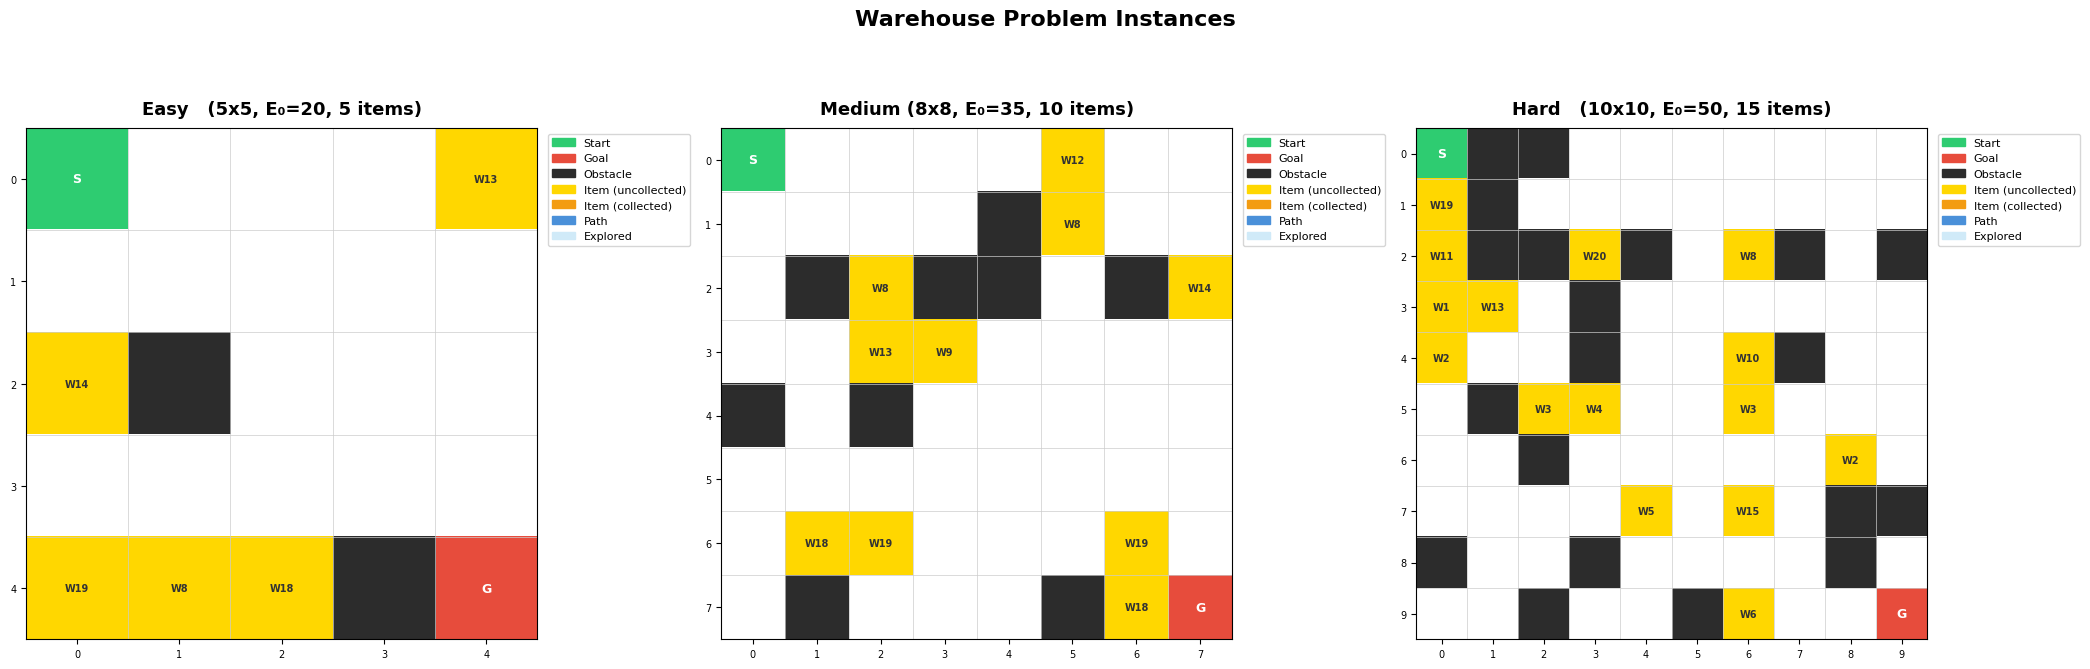

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (env, label) in zip(axes, [
        (env_easy,   'Easy   (5x5, E₀=20, 5 items)'),
        (env_medium, 'Medium (8x8, E₀=35, 10 items)'),
        (env_hard,   'Hard   (10x10, E₀=50, 15 items)'),
]):
    env.render(title=label, ax=ax)

plt.suptitle('Warehouse Problem Instances', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Result Dataclass & Path Reconstruction Utility

In [21]:
class SearchResult:
    """
    Container for the result of a search algorithm run.

    Attributes
    ----------
    found : bool - was a goal state reached?
    path : list of (row,col) - cell sequence from start to goal
    actions : list of str - action sequence
    collected_weight : int - W(π)
    path_length : int - L(π) = number of move actions
    nodes_expanded : int - how many nodes were popped from frontier
    nodes_generated : int - how many nodes were ever added to frontier
    time_sec : float - wall-clock time
    algorithm : str
    heuristic : str or None
    explored_cells : set of (row,col)  - for visualisation
    """
    def __init__(self):
        self.found           = False
        self.path            = []
        self.actions         = []
        self.collected_weight = 0
        self.path_length     = 0
        self.nodes_expanded  = 0
        self.nodes_generated = 0
        self.time_sec        = 0.0
        self.algorithm       = ''
        self.heuristic       = None
        self.explored_cells  = set()

    def __repr__(self):
        status = 'FOUND' if self.found else 'NOT FOUND'
        return (
            f"[{self.algorithm}({self.heuristic})] {status} | "
            f"W={self.collected_weight} | L={self.path_length} | "
            f"Expanded={self.nodes_expanded} | Generated={self.nodes_generated} | "
            f"Time={self.time_sec:.4f}s"
        )


def reconstruct_path(came_from, goal_state):
    """
    Trace back from goal_state through came_from dict.
    came_from maps state → (parent_state, action)
    Returns
    -------
    cells : list of (row,col) from start to goal
    actions : list of action strings
    """
    cells, actions = [], []
    state = goal_state
    while came_from[state] is not None:
        parent, action = came_from[state]
        cells.append((state[0], state[1]))
        actions.append(action)
        state = parent
    cells.append((state[0], state[1]))  # start
    cells.reverse()
    actions.reverse()
    return cells, actions


print("SearchResult and path reconstruction utilities defined.")

SearchResult and path reconstruction utilities defined.


## Algorithm 1 – Breadth-First Search (BFS)

### Theoretical Properties (from D2)
| Property | Value |
|---|---|
| **Complete?** | ✅ Yes (finite state space) |
| **Optimal (max weight)?** | ❌ No – finds shallowest goal, not max-weight |
| **Time Complexity** | O(b^d) = O(5^(E₀+k)) |
| **Space Complexity** | O(b^d) = O(5^(E₀+k)) |

BFS explores level by level. The first goal state it finds will have the **minimum number of moves** (minimum depth), not necessarily the maximum collected weight.

In [22]:
def bfs(env, max_nodes=500_000):
    """
    Breadth-First Search for the warehouse navigation problem.

    Expands states level-by-level (FIFO queue).
    Returns as soon as the first goal state is reached.

    Parameters
    ----------
    env       : WarehouseEnv
    max_nodes : safety cap on expansions (to avoid running forever on hard instances)

    Returns
    -------
    SearchResult
    """
    result = SearchResult()
    result.algorithm = 'BFS'

    start_time = time.perf_counter()

    initial = env.initial_state()

    # FIFO frontier: each entry is a state
    frontier = deque([initial])
    # came_from: state → (parent_state, action) | None for initial
    came_from = {initial: None}

    result.nodes_generated += 1   # initial state

    while frontier:
        if result.nodes_expanded >= max_nodes:
            print(f"  ⚠️  BFS hit node cap ({max_nodes}). Terminating early.")
            break

        state = frontier.popleft()
        result.nodes_expanded += 1
        result.explored_cells.add((state[0], state[1]))

        # Goal check
        if env.is_goal(state):
            result.found = True
            result.path, result.actions = reconstruct_path(came_from, state)
            result.collected_weight = env.collected_weight(state)
            result.path_length = sum(1 for a in result.actions
                                     if a.startswith('Move'))
            break

        # Expand successors
        for action, successor, _ in env.get_successors(state):
            if successor not in came_from:
                came_from[successor] = (state, action)
                frontier.append(successor)
                result.nodes_generated += 1

    result.time_sec = time.perf_counter() - start_time
    return result


print("✅ BFS algorithm defined.")

✅ BFS algorithm defined.


In [23]:
print("Running BFS on Easy instance...")
bfs_easy = bfs(env_easy)
print(bfs_easy)

print("\nRunning BFS on Medium instance...")
bfs_medium = bfs(env_medium)
print(bfs_medium)

print("\nRunning BFS on Hard instance (may be slow)...")
bfs_hard = bfs(env_hard, max_nodes=200_000)
print(bfs_hard)

Running BFS on Easy instance...
[BFS(None)] FOUND | W=14 | L=8 | Expanded=166 | Generated=249 | Time=0.0011s

Running BFS on Medium instance...
[BFS(None)] FOUND | W=74 | L=14 | Expanded=1553 | Generated=2271 | Time=0.0080s

Running BFS on Hard instance (may be slow)...
[BFS(None)] FOUND | W=44 | L=18 | Expanded=3586 | Generated=5521 | Time=0.0187s


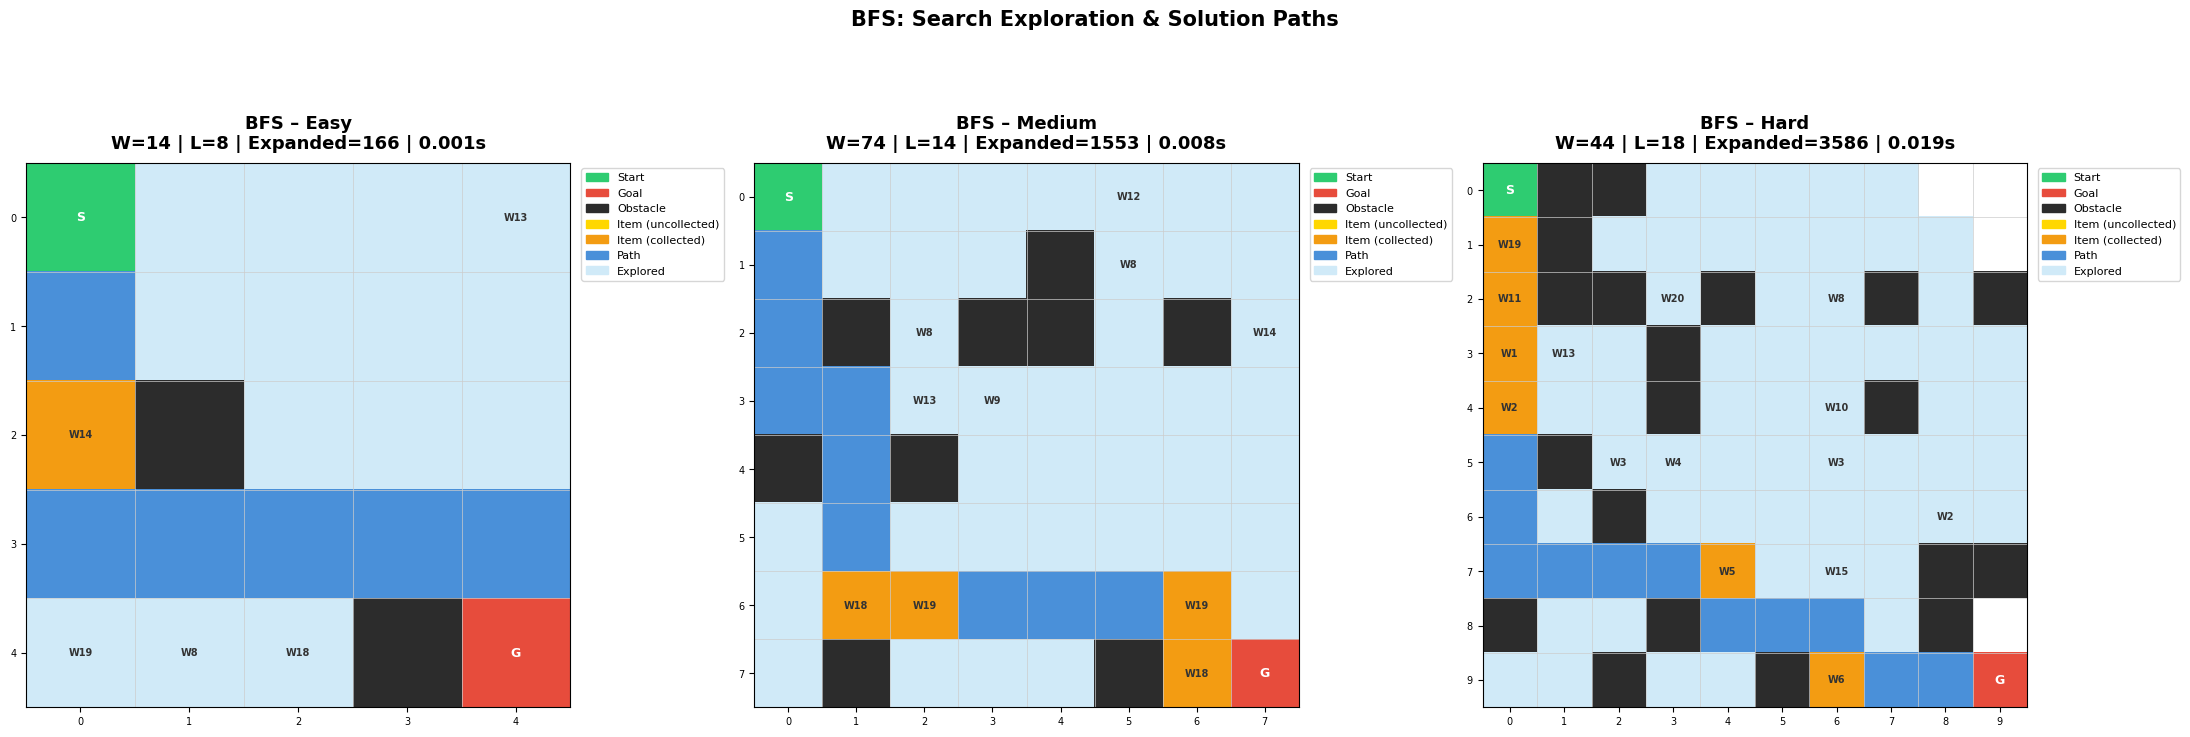

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (env, res, label) in zip(axes, [
    (env_easy,   bfs_easy,   'BFS – Easy'),
    (env_medium, bfs_medium, 'BFS – Medium'),
    (env_hard,   bfs_hard,   'BFS – Hard'),
]):
    info = (f'W={res.collected_weight} | L={res.path_length} | '
            f'Expanded={res.nodes_expanded} | {res.time_sec:.3f}s')
    env.render(
        path=res.path,
        explored=res.explored_cells,
        title=f'{label}\n{info}',
        ax=ax
    )

plt.suptitle('BFS: Search Exploration & Solution Paths', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### BFS – Key Observations

- BFS finds the **shallowest** (fewest moves) path to the goal.
- It explores enormous portions of the grid, explaining the high node count.
- The collected weight is **not guaranteed to be maximum** – BFS stops as soon as any goal is reached, even if a longer path would collect heavier items.
- This confirms the D2 analysis: **BFS is complete but not optimal for max-weight**.


## Algorithm 2 – Uniform Cost Search (UCS)

### Theoretical Properties (from D2)
| Property | Value |
|---|---|
| **Complete?** | ✅ Yes (finite state space, positive step costs) |
| **Optimal (min move cost)?** | ✅ Yes – always expands cheapest path first |
| **Optimal (max weight)?** | ❌ No – minimises moves, not maximises weight |
| **Time Complexity** | O(b^d) = O(5^(E₀+k)) |
| **Space Complexity** | O(b^d) = O(5^(E₀+k)) |

### How UCS differs from BFS

BFS uses a **FIFO queue** — all edges are treated equally.  
UCS uses a **min-heap (priority queue)** ordered by `g(n)`, the cumulative path cost so far.  

In our problem every Move action costs **1** and every Pickup costs **0**, so `g(n) = L(π)` (number of moves taken).  
That means UCS will select paths by total move cost, which corresponds to the shortest path length in this specific setup.  
The key conceptual difference is that **UCS generalises to non-uniform costs**, while BFS only works correctly for equal-cost transitions.



In [25]:
def ucs(env, max_nodes=500_000):
    """
    Uniform Cost Search for the warehouse navigation problem.

    Frontier is a min-heap ordered by g(n) = cumulative move cost.
    Since every Move costs 1 and Pickup costs 0:
        g(n) = number of move actions taken so far = L(π)

    A state is finalised (never re-expanded) the first time it is
    popped from the priority queue — guaranteed optimal g(n) at that
    point because all step costs are non-negative.

    Parameters
    ----------
    env       : WarehouseEnv
    max_nodes : safety cap on expansions

    Returns
    -------
    SearchResult
    """
    result = SearchResult()
    result.algorithm = 'UCS'

    start_time = time.perf_counter()

    initial = env.initial_state()

    # Heap entry: (g_cost, tie_break_counter, state)
    # tie_break_counter ensures stable ordering when g costs are equal
    counter  = 0
    frontier = [(0, counter, initial)]   # (g, counter, state)
    heapq.heapify(frontier)

    # best_g: state → lowest g cost seen so far
    # Allows lazy deletion: if we pop a state with g > best_g[state], skip it
    best_g    = {initial: 0}
    came_from = {initial: None}          # state → (parent, action)

    result.nodes_generated += 1

    while frontier:
        if result.nodes_expanded >= max_nodes:
            print(f"  ⚠️  UCS hit node cap ({max_nodes}). Terminating early.")
            break

        g, _, state = heapq.heappop(frontier)

        # Lazy deletion: skip stale entries
        if g > best_g.get(state, float('inf')):
            continue

        result.nodes_expanded += 1
        result.explored_cells.add((state[0], state[1]))

        # Goal check — done here (after pop) to guarantee optimal g
        if env.is_goal(state):
            result.found = True
            result.path, result.actions = reconstruct_path(came_from, state)
            result.collected_weight = env.collected_weight(state)
            result.path_length = sum(1 for a in result.actions
                                     if a.startswith('Move'))
            break

        # Expand successors
        for action, successor, step_cost in env.get_successors(state):
            new_g = g + step_cost   # step_cost = 1 for Move, 0 for Pickup
            if new_g < best_g.get(successor, float('inf')):
                best_g[successor]    = new_g
                came_from[successor] = (state, action)
                counter += 1
                heapq.heappush(frontier, (new_g, counter, successor))
                result.nodes_generated += 1

    result.time_sec = time.perf_counter() - start_time
    return result


print('✅ UCS algorithm defined.')

✅ UCS algorithm defined.
